In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv("insurance.csv")

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.shape

(1338, 7)

Text(0, 0.5, 'Count')

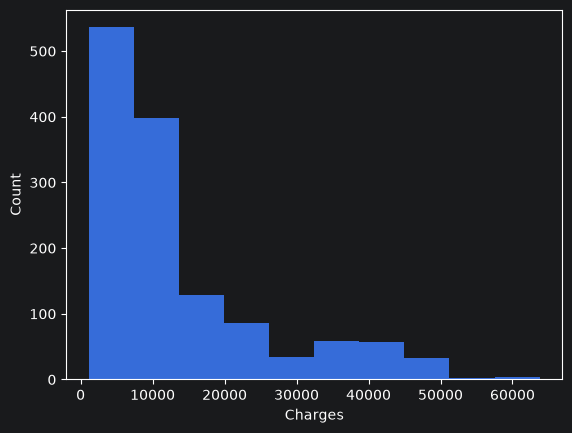

In [5]:
plt.hist(data['charges'])
plt.xlabel("Charges")
plt.ylabel("Count")

In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
mean = np.mean(data['charges'])
std = np.std(data['charges'])

In [13]:
(data['charges']- mean ) / std

0       0.298584
1      -0.953689
2      -0.728675
3       0.719843
4      -0.776802
          ...   
1333   -0.220551
1334   -0.914002
1335   -0.961596
1336   -0.930362
1337    1.311053
Name: charges, Length: 1338, dtype: float64

In [14]:
data['charges_z_score'] = (data['charges'] - mean) / std

In [15]:
data.head()

,age,sex,bmi,children,smoker,region,charges,charges_z_score
0,19,female,27.900,0,yes,southwest,16884.92400,0.298584
1,18,male,33.770,1,no,southeast,1725.55230,-0.953689
2,28,male,33.000,3,no,southeast,4449.46200,-0.728675
3,33,male,22.705,0,no,northwest,21984.47061,0.719843
4,32,male,28.880,0,no,northwest,3866.85520,-0.776802


In [18]:
data[data['charges_z_score']>2.5]

,age,sex,bmi,children,smoker,region,charges,charges_z_score
34,28,male,36.400,1,yes,southwest,51194.55914,3.132806
39,60,male,39.900,0,yes,southwest,48173.36100,2.883233
55,58,male,36.955,2,yes,northwest,47496.49445,2.827319
86,57,female,31.160,0,yes,northwest,43578.93940,2.503701
94,64,female,31.300,2,yes,southwest,47291.05500,2.810349
109,63,male,35.090,0,yes,southeast,47055.53210,2.790893
175,63,female,37.700,0,yes,southwest,48824.45000,2.937018
185,36,male,41.895,3,yes,northeast,43753.33705,2.518108
251,63,female,32.200,2,yes,southwest,47305.30500,2.811526
252,54,male,34.210,2,yes,southeast,44260.74990,2.560024


In [20]:
data['charges_z_score'].min()

np.float64(-1.003557345258499)

In [21]:
data['charges_z_score'].max()

np.float64(4.17166316317004)

In [22]:
outlier_indices = []

In [26]:
#Both values add to the same list
outlier_indices.extend(data.index[data['charges_z_score']>3].to_list())
outlier_indices.extend(data.index[data['charges_z_score']<-3].to_list())

In [27]:
outlier_indices

[34, 543, 577, 819, 1146, 1230, 1300]

In [28]:
new_data = data.drop(data.index[outlier_indices])

In [29]:
new_data.head()

,age,sex,bmi,children,smoker,region,charges,charges_z_score
0,19,female,27.900,0,yes,southwest,16884.92400,0.298584
1,18,male,33.770,1,no,southeast,1725.55230,-0.953689
2,28,male,33.000,3,no,southeast,4449.46200,-0.728675
3,33,male,22.705,0,no,northwest,21984.47061,0.719843
4,32,male,28.880,0,no,northwest,3866.85520,-0.776802


In [33]:
new_data.shape

(1331, 8)

In [35]:
new_data.drop('charges_z_score', axis = 1)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [36]:
new_data.shape

(1331, 8)

Text(0, 0.5, 'Count')

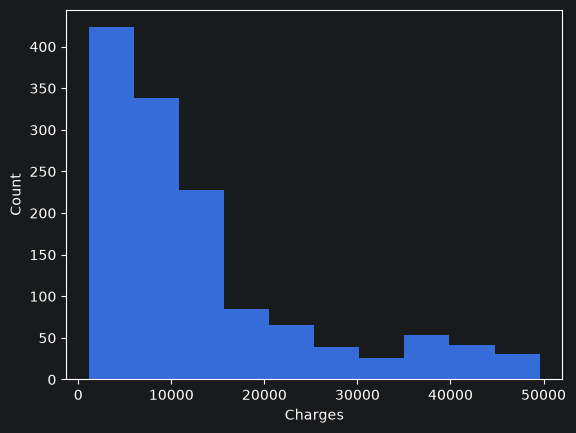

In [37]:
plt.hist(new_data['charges'])
plt.xlabel("Charges")
plt.ylabel("Count")